In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')

print(f'Using device: {device}')


Using device: mps


In [4]:
BASE_DIR = Path('.')
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'validation'
test_dir = BASE_DIR / 'test'

print('Train:', train_dir.resolve())
print('Validation:', val_dir.resolve())
print('Test:', test_dir.resolve())

assert train_dir.exists(), 'train folder not found'
assert val_dir.exists(), 'validation folder not found'
assert test_dir.exists(), 'test folder not found'

Train: /Users/ritesh/Downloads/clothing-dataset-small/train
Validation: /Users/ritesh/Downloads/clothing-dataset-small/validation
Test: /Users/ritesh/Downloads/clothing-dataset-small/test


In [5]:
IMG_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Classes:', train_dataset.classes)
print('Number of classes:', len(train_dataset.classes))
print('Train images:', len(train_dataset))
print('Validation images:', len(val_dataset))
print('Test images:', len(test_dataset))

Classes: ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']
Number of classes: 10
Train images: 3068
Validation images: 341
Test images: 372


## Modified Model


In [6]:
class ModifiedModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ModifiedModel().to(device)
print(model)

ModifiedModel(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): BatchNorm1d(128, ep

In [7]:
def train_model(model, optimizer, criterion, epochs):
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f'Epoch {epoch+1}/{epochs} | loss: {train_loss:.4f} | acc: {train_acc:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

    return history


In [8]:
# Training 
EPOCHS = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
)

history = train_model(model, optimizer, criterion, EPOCHS)

Epoch 1/15 | loss: 1.5989 | acc: 0.4821 | val_loss: 1.5156 | val_acc: 0.5044
Epoch 2/15 | loss: 1.1217 | acc: 0.6490 | val_loss: 1.2060 | val_acc: 0.5836
Epoch 3/15 | loss: 0.8318 | acc: 0.7415 | val_loss: 1.0075 | val_acc: 0.6804
Epoch 4/15 | loss: 0.6375 | acc: 0.8100 | val_loss: 0.9353 | val_acc: 0.6950
Epoch 5/15 | loss: 0.4442 | acc: 0.8745 | val_loss: 0.9371 | val_acc: 0.6891
Epoch 6/15 | loss: 0.3266 | acc: 0.9110 | val_loss: 0.9322 | val_acc: 0.7126
Epoch 7/15 | loss: 0.2296 | acc: 0.9498 | val_loss: 0.8737 | val_acc: 0.7302
Epoch 8/15 | loss: 0.1542 | acc: 0.9687 | val_loss: 0.9191 | val_acc: 0.7126
Epoch 9/15 | loss: 0.1284 | acc: 0.9723 | val_loss: 0.9517 | val_acc: 0.7126
Epoch 10/15 | loss: 0.1061 | acc: 0.9782 | val_loss: 0.9034 | val_acc: 0.7126
Epoch 11/15 | loss: 0.0843 | acc: 0.9850 | val_loss: 0.9849 | val_acc: 0.6804
Epoch 12/15 | loss: 0.0664 | acc: 0.9876 | val_loss: 0.9079 | val_acc: 0.7449
Epoch 13/15 | loss: 0.0743 | acc: 0.9840 | val_loss: 0.9528 | val_acc: 0.

In [9]:
def evaluate_model(model, criterion):
    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    return test_running_loss / len(test_loader.dataset), test_correct / test_total

In [10]:
test_loss, test_acc = evaluate_model(model, criterion)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')


Test Loss: 1.6004
Test Accuracy: 0.5430


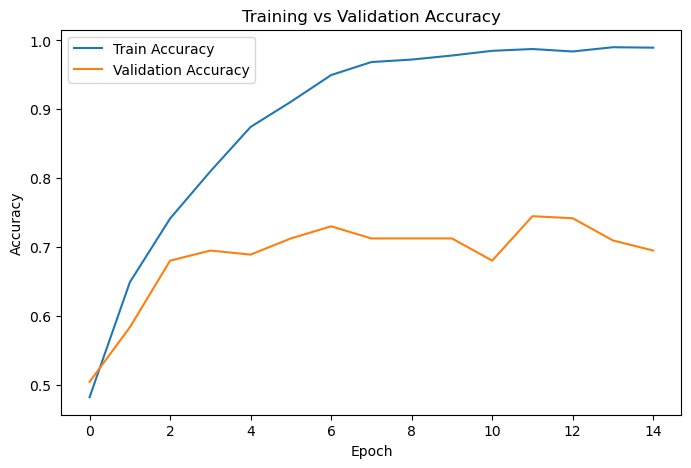

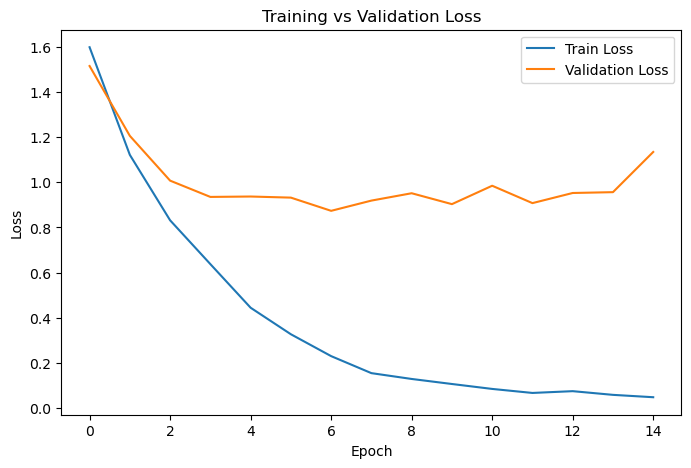

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [12]:
import torch
torch.save(model.state_dict(), 'clothing_model.pth')